#### This notebook reproduces figure A2 in "Age-related vulnerability greatly amplifies the risk of uncompensable heat" by Kong et al.


In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# create colormap
colors=np.array([[255,255,255],
                 [255,245,240],
                 [254,224,210],
                 [252,187,161],
                 [252,146,114],
                 [251,106,74],
                 [239,59,44],
                 [203,24,29],
                 [165,15,21],
                 [103,0,13]])
cmap=mpl.colors.ListedColormap(colors/255.)

# directory to data; you might want to change it to your own directory
path='../data/'

# read in hourly probability of threshold exceedance for different age groups at 8 major cities under 1.5-4°C warming
data=xr.open_dataset(path+'Hourly_probability_of_threshold_exceedance.nc').probability


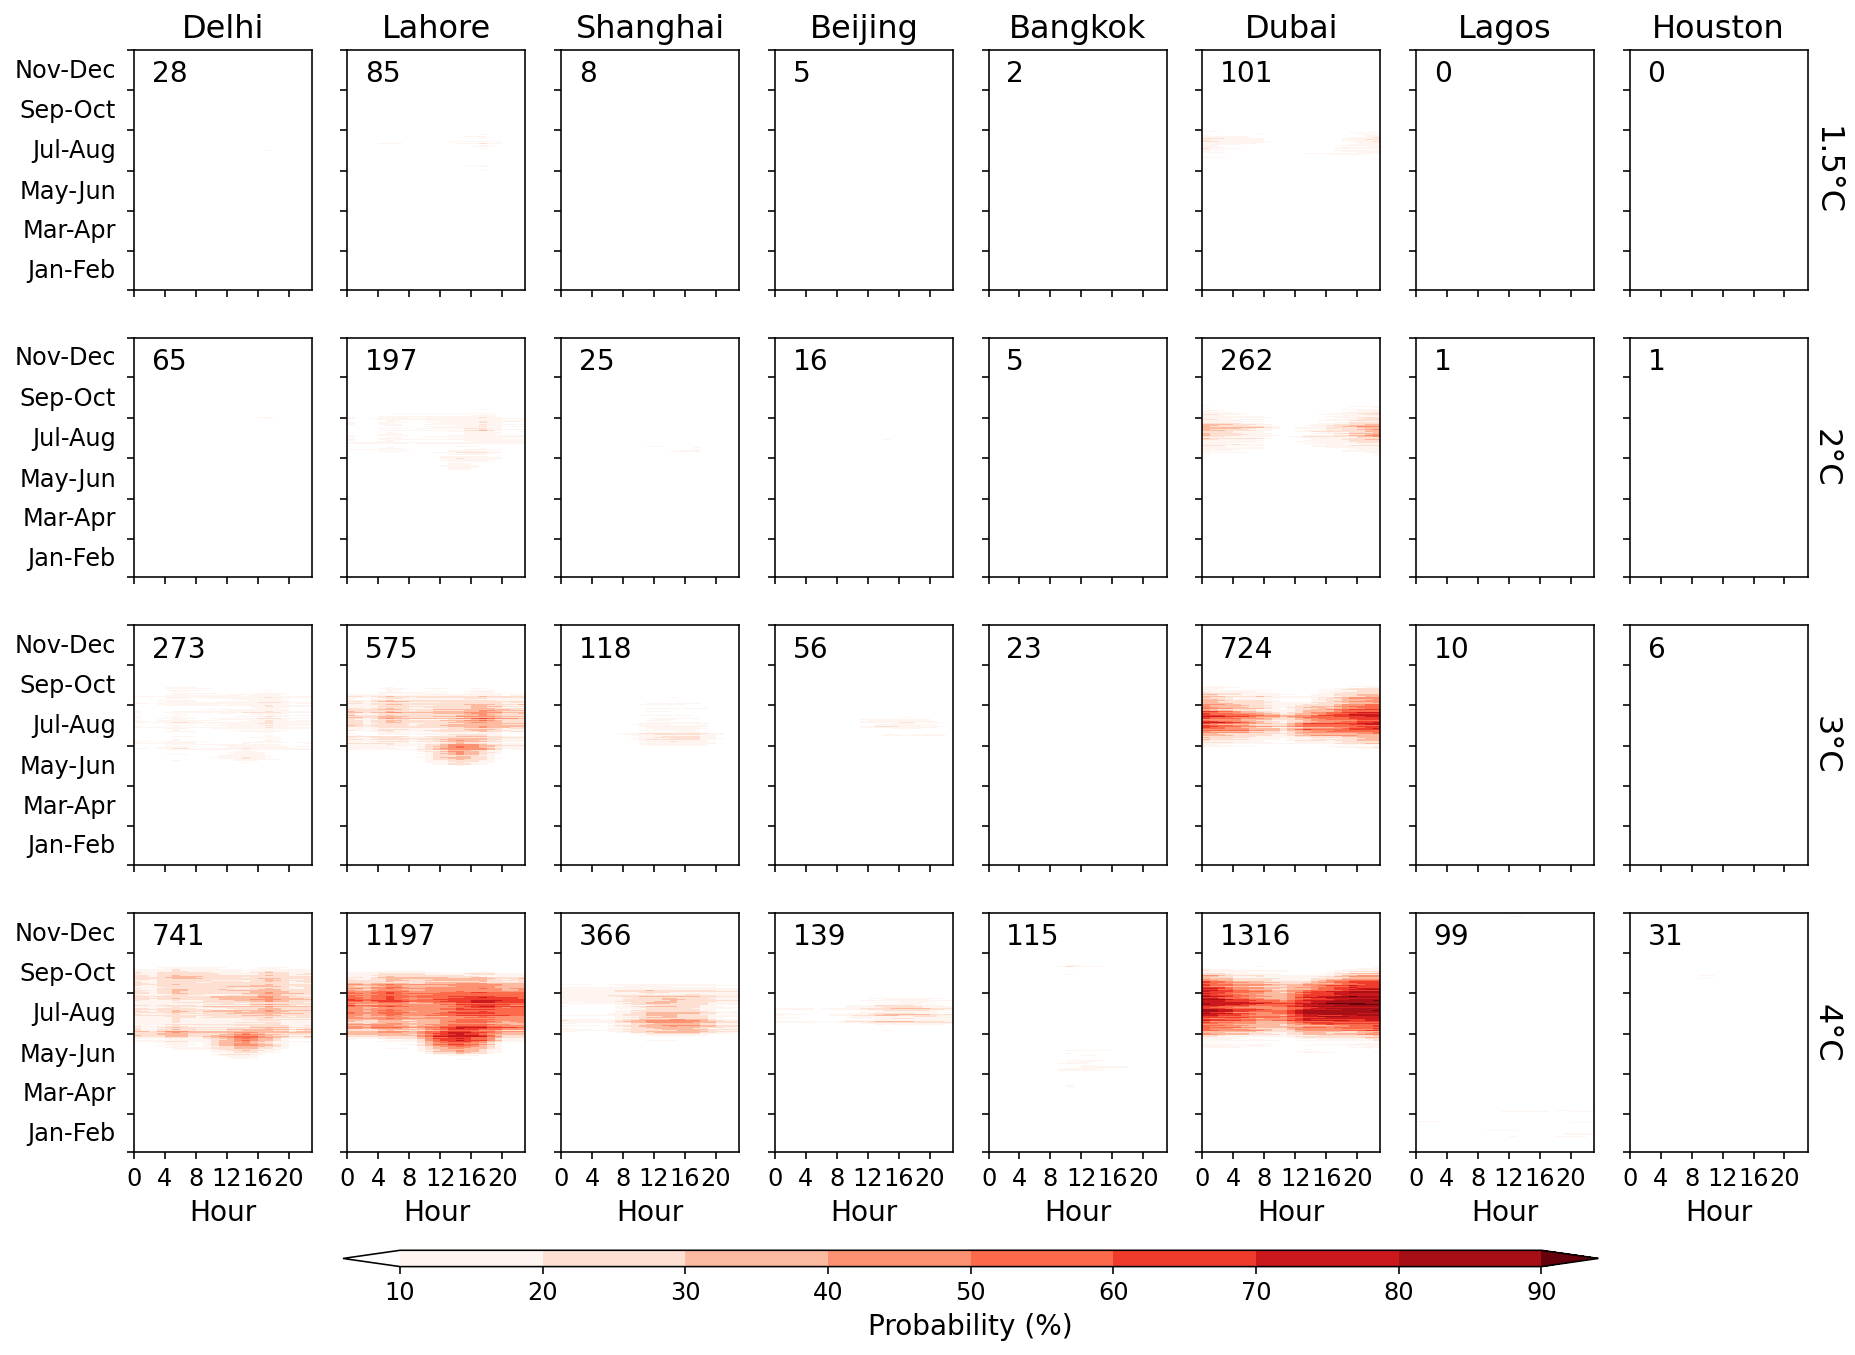

In [5]:
age='young' # for young people
# function to plot each individual panel of the figure
def subplot(ax,data):
    X=data['hour'].values
    Y=data['day'].values
    X,Y=np.meshgrid(X,Y)
    levels=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    norm=mpl.colors.BoundaryNorm(levels,ncolors=len(levels)+1,extend='both')
    g=ax.pcolormesh(X,Y,data,norm=norm,cmap=cmap)
    ax.set_xticks([0,4,8,12,16,20])
    ax.set_yticks([1,59.5,120.5,181.5,243.5,304.5,365])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='both', labelsize=12)
    return g

# plot the whole figure
fig = plt.figure(figsize=(15,12)) # create figure
k=0
for X in ['1.5','2','3','4']: # loop over warming levels
    for city in ['Delhi','Lahore','Shanghai','Beijing','Bangkok','Dubai','Lagos','Houston']: # loop over cities
        ax=fig.add_subplot(4,8,k+1)
        g=subplot(ax,data.sel(city=city).sel(X=X).sel(age=age).squeeze())
        # denote annual total number of hours exceeding heat compensability limits 
        ax.text(x=0.1,y=0.9,s=str(round(data.sel(age=age).sel(X=X).sel(city=city).sum(('day','hour')).values.item())),
                transform=ax.transAxes,va='center', ha='left',fontsize=14)
        k+=1
    
axes=fig.get_axes()

label_positions = [30, 90, 150,212,273,334]  # positions to put y-axis ticklabels
labels = ['Jan-Feb', 'Mar-Apr', 'May-Jun','Jul-Aug','Sep-Oct','Nov-Dec']
for pos, label in zip(label_positions, labels):
    for k in [0,8,16,24]:
        axes[k].text(x=-0.1, y=pos, s=label, va='center', ha='right', transform=axes[k].get_yaxis_transform(),fontsize=12)
for k in [24,25,26,27,28,29,30,31]:
    axes[k].set_xticklabels(['0','4','8','12','16','20'],fontsize=12)
    axes[k].set_xlabel('Hour',fontsize=14)
    
anno_opts = dict(xy=(0.5, 1.05), xycoords='axes fraction',va='baseline', ha='center')
for k in range(8):
    axes[k].annotate(data['city'].values[k], **anno_opts,fontsize=16)  

anno_opts = dict(xy=(1.1, 0.5), xycoords='axes fraction',va='center', ha='center',rotation=270)
axes[7].annotate('1.5°C', **anno_opts,fontsize=16)  
axes[15].annotate('2°C', **anno_opts,fontsize=16)  
axes[23].annotate('3°C', **anno_opts,fontsize=16)  
axes[31].annotate('4°C', **anno_opts,fontsize=16)  

cb=fig.colorbar(g,ax=axes,orientation='horizontal',pad=0.075,shrink=0.75,fraction=.08,aspect=70,
                ticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
tick_labels=['10','20','30','40','50','60','70','80','90']
cb.set_ticklabels(tick_labels)
cb.set_label(label='Probability (%)', size=14)
cb.ax.tick_params(labelsize=12)

**Figure A2**: Same as Fig. 3 except for the young